# Inadimplência no Pix Parcelado — 2. Estatística e Teste A/B

Continuando o estudo do notebook 1. Aqui eu quero confirmar com testes
estatísticos se as diferenças que vi nos gráficos são "de verdade" ou podem ser
só coincidência, e também simular um teste A/B: o banco (fictício) testou duas
formas de lembrar o cliente inadimplente de pagar, e quero ver qual funcionou
melhor pra recuperar esse cliente.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/pix_parcelado.csv")
df.head()


,cliente_id,idade,renda_estimada,valor_compra,qtd_parcelas,ja_usou_pix_parcelado_antes,score_credito,inadimplente,estrategia_lembrete,recuperou
0,CLI1000,22,2369.71,1814.17,4,1,834,0,NaN,0
1,CLI1001,43,1154.48,2600.64,4,0,802,0,NaN,0
2,CLI1002,21,2428.98,2223.55,9,0,629,0,NaN,0
3,CLI1003,37,2568.09,1837.05,9,0,516,1,Lembrete com opção de renegociar,0
4,CLI1004,41,5432.11,1546.46,9,0,506,0,NaN,0


## A diferença entre "já usou antes" e "primeira vez" é real ou coincidência?

Pra não ficar só no achismo olhando gráfico, rodei um teste qui-quadrado, que
serve justamente pra ver se duas variáveis categóricas (nesse caso, "já usou
antes" e "ficou inadimplente") têm relação real ou se a diferença que vi pode
ser só acaso da amostra.


In [2]:
tabela_contingencia = pd.crosstab(df["ja_usou_pix_parcelado_antes"], df["inadimplente"])
print(tabela_contingencia)

chi2, p, dof, esperado = stats.chi2_contingency(tabela_contingencia)
print(f"\nqui-quadrado: {chi2:.2f}")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("\nComo o p-valor é menor que 0.05, dá pra dizer que existe sim uma relação"
          " entre já ter usado o produto antes e a chance de ficar inadimplente"
          " (não é só coincidência da amostra).")
else:
    print("\nComo o p-valor é maior que 0.05, não dá pra afirmar com confiança que"
          " existe relação entre as duas coisas.")


inadimplente                    0    1
ja_usou_pix_parcelado_antes           
0                            1284  544
1                             873  299

qui-quadrado: 6.17
p-valor: 0.0130

Como o p-valor é menor que 0.05, dá pra dizer que existe sim uma relação entre já ter usado o produto antes e a chance de ficar inadimplente (não é só coincidência da amostra).


## Score de crédito x inadimplência

Queria ver também se o score de crédito (que é uma variável clássica em análise
de crédito) separa bem quem paga de quem atrasa, e se essa diferença é
estatisticamente significativa (teste t).


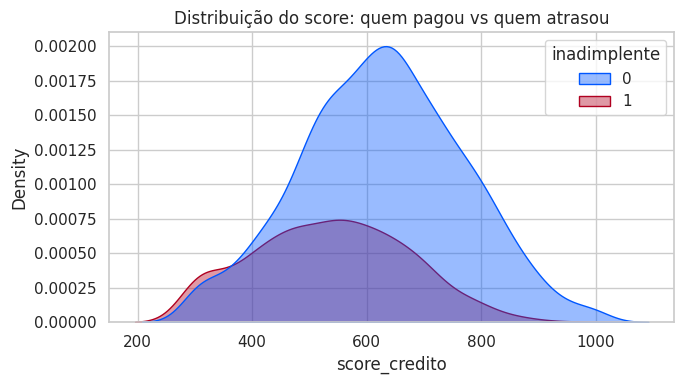

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(data=df, x="score_credito", hue="inadimplente", fill=True, alpha=0.4,
            palette={0: "#0057FF", 1: "#B00020"}, ax=ax)
ax.set_title("Distribuição do score: quem pagou vs quem atrasou")
plt.tight_layout()
plt.savefig("../images/score_inadimplencia.png", dpi=120)
plt.show()


In [4]:
score_pagou = df.loc[df["inadimplente"] == 0, "score_credito"]
score_atrasou = df.loc[df["inadimplente"] == 1, "score_credito"]

t, p = stats.ttest_ind(score_pagou, score_atrasou, equal_var=False)
print(f"média score (pagou): {score_pagou.mean():.0f}")
print(f"média score (atrasou): {score_atrasou.mean():.0f}")
print(f"p-valor: {p:.2e}")


média score (pagou): 627
média score (atrasou): 536
p-valor: 4.24e-56


O gráfico já mostra visualmente que quem atrasa tende a ter um score mais baixo,
e o teste t confirma que essa diferença não é coincidência (p-valor bem menor que
0.05).


## Teste A/B: qual lembrete de cobrança funciona melhor?

Entre os clientes que ficaram inadimplentes, metade recebeu um **lembrete
simples** (notificação padrão) e a outra metade recebeu um **lembrete com opção
de renegociar** a parcela direto no app. A métrica que importa aqui é: quantos
desses clientes voltaram a ficar em dia (recuperou)?

Pra comparar as duas proporções de forma estatística (e não só olhar o número
cru), usei um teste Z de proporções, que é basicamente o teste padrão pra
comparar taxa de conversão entre dois grupos — a mesma lógica usada em teste A/B
de produto/marketing.


In [5]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

inad = df[df["inadimplente"] == 1].copy()

grupo_a = inad[inad["estrategia_lembrete"] == "Lembrete simples"]
grupo_b = inad[inad["estrategia_lembrete"] == "Lembrete com opção de renegociar"]

recuperados = np.array([grupo_a["recuperou"].sum(), grupo_b["recuperou"].sum()])
totais = np.array([len(grupo_a), len(grupo_b)])
taxas = recuperados / totais

print(f"Grupo A (lembrete simples):        {recuperados[0]}/{totais[0]} = {taxas[0]:.1%}")
print(f"Grupo B (lembrete com renegociar):  {recuperados[1]}/{totais[1]} = {taxas[1]:.1%}")

z_stat, p_value = proportions_ztest(recuperados, totais)
print(f"\nestatística Z: {z_stat:.2f}")
print(f"p-valor: {p_value:.4f}")

ci_a = proportion_confint(recuperados[0], totais[0], alpha=0.05, method="wilson")
ci_b = proportion_confint(recuperados[1], totais[1], alpha=0.05, method="wilson")
print(f"\nintervalo de confiança 95% grupo A: [{ci_a[0]:.1%}, {ci_a[1]:.1%}]")
print(f"intervalo de confiança 95% grupo B: [{ci_b[0]:.1%}, {ci_b[1]:.1%}]")

if p_value < 0.05:
    print("\n=> a diferença é estatisticamente significativa, então dá pra dizer que"
          " o lembrete com opção de renegociar realmente recupera mais gente, não é"
          " só sorte da amostra.")
else:
    print("\n=> não deu pra confirmar estatisticamente que um lembrete é melhor que"
          " o outro com esse tamanho de amostra.")


Grupo A (lembrete simples):        105/381 = 27.6%
Grupo B (lembrete com renegociar):  182/462 = 39.4%

estatística Z: -3.61
p-valor: 0.0003

intervalo de confiança 95% grupo A: [23.3%, 32.3%]
intervalo de confiança 95% grupo B: [35.0%, 43.9%]

=> a diferença é estatisticamente significativa, então dá pra dizer que o lembrete com opção de renegociar realmente recupera mais gente, não é só sorte da amostra.


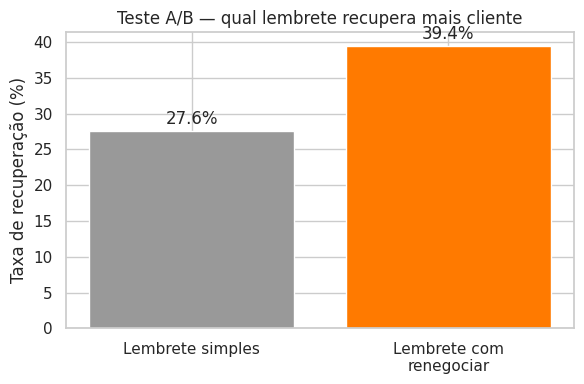

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
labels = ["Lembrete simples", "Lembrete com\nrenegociar"]
ax.bar(labels, taxas * 100, color=["#999999", "#FF7A00"])
ax.set_ylabel("Taxa de recuperação (%)")
ax.set_title("Teste A/B — qual lembrete recupera mais cliente")
for i, v in enumerate(taxas * 100):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("../images/teste_ab_recuperacao.png", dpi=120)
plt.show()


## Conclusão desse notebook

- A diferença entre cliente recorrente e cliente novo é real (qui-quadrado deu
  significativo)
- Score de crédito realmente separa bem quem paga de quem atrasa (teste t
  significativo)
- No teste A/B, o lembrete com opção de renegociar parece recuperar mais cliente
  do que o lembrete simples, e a diferença é estatisticamente significativa

Se fosse um cenário real, o próximo passo seria rodar esse teste com mais tempo/
amostra antes de migrar 100% da base pro lembrete novo, e acompanhar se o
resultado se mantém em diferentes perfis de cliente.
